In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pyomo.environ as pyo
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from pull_prices import merged_df_clean, merged_df_spike
from params import nodes, mcp, mdp, e, fee

# Create output folder
BASE_DIR = os.getcwd()
PLOT_DIR = os.path.join(BASE_DIR, "results", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print("Plots will be saved in:", PLOT_DIR)

2026-04-25 19:19:17 - DEBUG - Found 1 files: ['20251222_20251222_PRC_AS_DAM_v12.csv']
2026-04-25 19:19:17 - DEBUG - Parsing file: 20251222_20251222_PRC_AS_DAM_v12.csv
 47%|████▋     | 7/15 [00:45<00:52,  6.53s/it]2026-04-25 19:19:21 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_AS', 'version': 12}, 'params': {'market_run_id': ['DAM', 'HASP'], 'anc_type': ['ALL', 'NR', 'RD', 'RMD', 'RMU', 'RU', 'SR'], 'anc_region': ['ALL', 'AS_CAISO', 'AS_SP26_EXP', 'AS_SP26', 'AS_CAISO_EXP', 'AS_NP26_EXP', 'AS_NP26']}}
2026-04-25 19:19:21 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_AS&version=12&market_run_id=DAM&anc_type=ALL&anc_region=ALL&startdatetime=20251223T08:00-0000&enddatetime=20251224T08:00-0000
2026-04-25 19:19:23 - DEBUG - Found 1 files: ['20251223_20251223_PRC_AS_DAM_v12.csv']
2026-04-25 19:19:23 - DEBUG - Parsing file: 20251223_20251223_PRC_AS_DAM_v12.csv
 53%|█████▎    | 8/15 [00:51<00:44, 

[AS] ✓ 2025-12-16 → 2025-12-31
[AS] Cached to cache_as_20230101_20251231.pkl
[MERGE] LMP range:      2023-01-12 08:00:00 → 2025-12-31 07:00:00
[MERGE] AS range:       2023-01-01 08:00:00 → 2025-12-31 07:00:00
[MERGE] Final shape: (77832, 9)
Plots will be saved in: d:\battery-storage-optimization-energy-ancillary\results\plots


In [32]:
def compute_ewma_baseline(df):
    """Create a smooth expected-price baseline using an exponentially weighted moving average."""
    if df is None:
        raise ValueError("Received None dataframe")

    df = df.copy()

    if "SP15" not in df.columns:
        raise KeyError("SP15 column missing")

    # Use the recent history more strongly than the distant past.
    df["expected_price"] = df["SP15"].ewm(span=24, adjust=False).mean()

    return df

In [33]:
def prepare_timeseries(df):
    """Collapse the node-level table into one hourly time series."""

    # Average the market values across nodes so the optimizer sees one price per hour.
    df_ts = df.groupby("datetime").agg({
        "SP15": "mean",
        "NonSpin": "mean",
        "RegDown": "mean",
        "RegUp": "mean",
        "Spin": "mean"
    }).reset_index()

    df_ts = df_ts.sort_values("datetime").reset_index(drop=True)

    return df_ts

In [34]:
# =========================
# 🔹 GRAPH (LEARNED)
# =========================
def build_graph(df):

    pivot = df.pivot(index="datetime", columns="node", values="SP15")
    pivot = pivot.ffill()

    A = pivot.corr().values
    np.fill_diagonal(A, 0)

    D = np.diag(A.sum(axis=1))
    L = D - A

    return L

In [35]:
def compute_anomaly(df):
    """Compute a blended 0-1 anomaly score without leaking future data.
 
    IsolationForest and LOF are fitted on the training window only, then
    applied to the full series in predict mode.  This mirrors real
    deployment: the detector learns what "normal" looks like from history
    and flags deviations in new data.
    """
    df = df.copy()
 
    if "expected_price" not in df.columns:
        raise KeyError("expected_price missing — run train_vae first")
 
    # Retrieve the split point stored by train_vae.
    split = df.attrs.get("train_split_idx", int(len(df) * VAE_TRAIN_FRAC))
 
    X       = df[["SP15"]].values
    X_train = X[:split]
 
    # ------------------------------------------------------------------
    # Fit on training window, score on full series.
    # LOF requires novelty=True to call .predict() on new data.
    # ------------------------------------------------------------------
    iso = IsolationForest(contamination=0.05, random_state=42)
    iso.fit(X_train)
    df["iso"] = (iso.predict(X) == -1).astype(int)
 
    lof = LocalOutlierFactor(novelty=True)
    lof.fit(X_train)
    df["lof"] = (lof.predict(X) == -1).astype(int)
 
    # Reconstruction residual (works for both windows).
    df["res"] = (df["SP15"] - df["expected_price"]).abs()
 
    # Scale residuals using only the training distribution so the
    # held-out window is not normalised against its own extremes.
    res_train_max = df["res"].iloc[:split].max()
    res_train_min = df["res"].iloc[:split].min()
    denom = res_train_max - res_train_min
    df["res"] = (df["res"] - res_train_min) / (denom if denom > 1e-8 else 1.0)
    df["res"] = df["res"].clip(0, None)   # held-out can exceed 1 — that is fine,
                                          # it just means a very large deviation
 
    # Blend and normalise using training-window statistics.
    df["anomaly"] = df["res"] + df["iso"] + df["lof"]
 
    anom_train_min = df["anomaly"].iloc[:split].min()
    anom_train_max = df["anomaly"].iloc[:split].max()
    denom = anom_train_max - anom_train_min
    df["anomaly"] = (df["anomaly"] - anom_train_min) / (denom if denom > 1e-8 else 1.0)
    df["anomaly"] = df["anomaly"].clip(0, None)   # held-out scores can exceed 1;
                                                  # clip to 1 in classify_anomaly
 
    return df

In [36]:
def classify_anomaly(df, window=6, persist_threshold=2):
    """Label which anomalies are likely genuine market events vs noise.
 
    An anomaly is classified as genuine when ALL three conditions hold:
      1. Persistence  — at least persist_threshold neighbouring hours also
                        score as anomalous (rules out one-off data errors).
      2. Mean reversion — the average price over the next `window` hours is
                          lower than the current price (spike, not a step-up).
      3. Slow rate-of-change — the percentage jump from the previous hour is
                               below 50 % (rules out data glitches).
 
    The final anomaly_adjusted score boosts genuine spikes by 1.5× and
    suppresses noise by 0.3×, then clips to [0, 1].
    """
    df = df.copy()
 
    # Clip anomaly scores that may exceed 1 in the held-out window.
    df["anomaly"] = df["anomaly"].clip(0, 1)
 
    df["roc"] = df["SP15"].diff().abs()
    df["roc"] = df["roc"] / (df["SP15"].shift(1).abs() + 1e-8)
    df["roc"] = df["roc"].fillna(0)
 
    df["anom_binary"] = (df["anomaly"] > 0.5).astype(int)
    df["persistence"] = (
        df["anom_binary"].rolling(window, center=True, min_periods=1).sum()
    )
 
    df["local_mean"] = df["SP15"].rolling(window, center=True, min_periods=1).mean()
    df["local_std"]  = df["SP15"].rolling(window, center=True, min_periods=1).std().fillna(1)
    df["z_score"]    = (df["SP15"] - df["local_mean"]) / df["local_std"]
 
    df["future_mean"] = df["SP15"].shift(-window).rolling(window, min_periods=1).mean()
    df["reverts"]     = (df["future_mean"] < df["SP15"]).astype(int)
 
    df["is_genuine"] = (
        (df["persistence"] >= persist_threshold)
        & (df["reverts"] == 1)
        & (df["roc"] < 0.5)
    ).astype(int)
 
    df["anomaly_adjusted"] = df["anomaly"] * np.where(df["is_genuine"], 1.5, 0.3)
    df["anomaly_adjusted"] = df["anomaly_adjusted"].clip(0, 1)
 
    return df

In [37]:
from params import mcp, mdp, e, fee

try:
    from params import degradation_cost
except ImportError:
    degradation_cost = 2.5  # Fallback if not defined in params.py

VALID_MODES = {"baseline", "penalised", "opportunistic"}

def optimize(df, L, mode="baseline", anomaly_sensitivity=0.3):
    """Solve the dispatch problem for a given price series and operating mode."""
    if mode not in VALID_MODES:
        raise ValueError(f"Unknown mode '{mode}'. Choose from {VALID_MODES}")

    df = df.copy().reset_index(drop=True)
    df["anomaly"]    = df["anomaly"].fillna(0).clip(0, 1)
    df["is_genuine"] = df["is_genuine"].fillna(0)

    # Pyomo builds an optimisation model from these time-series inputs.
    model = pyo.ConcreteModel()
    T = len(df)
    model.t = pyo.RangeSet(0, T - 1)

    # Preload the hourly series into the model for fast access inside the LP.
    model.price    = pyo.Param(model.t, initialize=lambda m, t: float(df["SP15"].iloc[t]))
    model.anom     = pyo.Param(model.t, initialize=lambda m, t: float(df["anomaly"].iloc[t]))
    model.genuine  = pyo.Param(model.t, initialize=lambda m, t: float(df["is_genuine"].iloc[t]))

    # Decision variables: buy, sell, and state of charge.
    model.buy  = pyo.Var(model.t, bounds=(0, mcp))
    model.sell = pyo.Var(model.t, bounds=(0, mdp))
    model.soc  = pyo.Var(model.t, bounds=(0, mcp))

    # State of charge follows the battery physics from one hour to the next.
    def soc_rule(m, t):
        if t == 0:
            return m.soc[t] == mcp
        return m.soc[t] == m.soc[t-1] + m.buy[t] * e - m.sell[t] / e

    model.soc_c = pyo.Constraint(model.t, rule=soc_rule)

    # Selling is limited by the energy stored before the current hour starts.
    def sell_energy_rule(m, t):
        if t == 0:
            return m.sell[t] == 0
        return m.sell[t] <= e * m.soc[t - 1]

    model.sell_energy_c = pyo.Constraint(model.t, rule=sell_energy_rule)

    # Charging cannot push the battery above its capacity.
    def buy_headroom_rule(m, t):
        if t == 0:
            return pyo.Constraint.Skip
        return m.buy[t] * e <= mcp - m.soc[t - 1]

    model.buy_headroom_c = pyo.Constraint(model.t, rule=buy_headroom_rule)

    # Each mode uses a different sell cap.
    def sell_limit_rule(m, t):
        if mode == "baseline":
            return m.sell[t] <= mdp
        elif mode == "penalised":
            return m.sell[t] <= mdp * (1 - anomaly_sensitivity * m.anom[t])
        elif mode == "opportunistic":
            return m.sell[t] <= mdp * (
                1
                + anomaly_sensitivity * m.anom[t] * m.genuine[t]
                - anomaly_sensitivity * m.anom[t] * (1 - m.genuine[t])
            )

    model.sell_limit = pyo.Constraint(model.t, rule=sell_limit_rule)

    # The objective rewards profitable trades and subtracts fees plus degradation cost.
    def obj(m):
        if mode == "baseline":
            return sum(
                m.sell[t] * m.price[t]
                - m.buy[t] * m.price[t]
                - (fee + degradation_cost) * (m.sell[t] + m.buy[t])
                for t in m.t 
            )

        elif mode == "penalised":
            return sum(
                m.sell[t] * m.price[t] * (1 - anomaly_sensitivity * m.anom[t])
                - m.buy[t] * m.price[t] * (1 + anomaly_sensitivity * m.anom[t])
                - (fee + degradation_cost) * (m.sell[t] + m.buy[t])
                for t in m.t 
            )

        elif mode == "opportunistic":
            return sum(
                m.sell[t] * m.price[t] * (
                    1 + anomaly_sensitivity * m.anom[t] * m.genuine[t]
                    - anomaly_sensitivity * m.anom[t] * (1 - m.genuine[t])
                )
                - m.buy[t] * m.price[t] * (
                    1 - anomaly_sensitivity * m.anom[t] * m.genuine[t]
                    + anomaly_sensitivity * m.anom[t] * (1 - m.genuine[t])
                )
                - (fee + degradation_cost) * (m.sell[t] + m.buy[t])
                for t in m.t 
            )

    model.obj = pyo.Objective(rule=obj, sense=pyo.maximize)

    # Solve the model with HiGHS and stop if the result is not optimal.
    solver_result = pyo.SolverFactory("highs").solve(model)

    from pyomo.opt import SolverStatus, TerminationCondition

    if (solver_result.solver.status != SolverStatus.ok or
        solver_result.solver.termination_condition
            != TerminationCondition.optimal):
        raise RuntimeError(
            f"Solver failed: {solver_result.solver.termination_condition}"
        )

    # Extract the hourly SOC path and the final objective value.
    soc    = [pyo.value(model.soc[t]) for t in model.t]
    profit = pyo.value(model.obj) or 0.0

    return profit, soc

In [38]:
# =========================
# 🔹 PLOTTING (SAVE ONLY)
# =========================

def plot_price_comparison(df, name):

    plt.figure(figsize=(12,5))
    plt.plot(df["SP15"].values, label="Actual Price")
    plt.plot(df["expected_price"].values, label="Expected Price")

    plt.title("Price vs Expected Price")
    plt.legend()
    plt.grid()

    filepath = os.path.join(PLOT_DIR, f"{name}_price.png")
    plt.savefig(filepath)
    plt.close()


def plot_soc_comparison(base_soc, anom_soc, name):

    plt.figure(figsize=(12,5))
    plt.plot(base_soc, label="Baseline SOC")
    plt.plot(anom_soc, label="Anomaly SOC")

    plt.title("SOC Comparison")
    plt.legend()
    plt.grid()

    filepath = os.path.join(PLOT_DIR, f"{name}_soc.png")
    plt.savefig(filepath)
    plt.close()


def plot_volatility(df, name):

    df = df.copy()
    df["volatility"] = df["SP15"].rolling(24).std()

    plt.figure(figsize=(12,4))
    plt.plot(df["volatility"], color="purple")

    plt.title("Volatility")
    plt.grid()

    filepath = os.path.join(PLOT_DIR, f"{name}_volatility.png")
    plt.savefig(filepath)
    plt.close()


def plot_profit(c_base, c_pen, c_opp, a_base, a_pen, a_opp):
    x     = np.arange(3)
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, [c_base, c_pen, c_opp], width, label="Clean",  color="steelblue")
    ax.bar(x,         [a_base, a_pen, a_opp], width, label="Attack", color="crimson")

    ax.set_xticks(x)
    ax.set_xticklabels(["Baseline", "Penalised", "Opportunistic"])
    ax.set_title("Profit Comparison Across Strategies and Scenarios")
    ax.set_ylabel("Profit ($)")
    ax.legend()
    ax.grid(axis="y")

    filepath = os.path.join(PLOT_DIR, "profit_comparison.png")
    plt.savefig(filepath)
    plt.close()

In [40]:
VAE_EPOCHS     = 50
VAE_BATCH      = 16
VAE_LR         = 1e-3
VAE_SEQ_LEN    = 24      # one sequence = one 24-hour day
VAE_LATENT_DIM = 8
VAE_TRAIN_FRAC = 0.80

In [41]:
class VAE(nn.Module):
    """Small variational autoencoder that learns a smooth daily price profile."""
 
    def __init__(self, input_dim=VAE_SEQ_LEN, latent_dim=VAE_LATENT_DIM):
        super().__init__()
        self.fc1      = nn.Linear(input_dim, 32)
        self.fc_mu    = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.fc2      = nn.Linear(latent_dim, 32)
        self.fc3      = nn.Linear(32, input_dim)
 
    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)
 
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std
 
    def decode(self, z):
        return self.fc3(torch.relu(self.fc2(z)))
 
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
 
 
def _vae_loss(recon, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon, x)
    # Sum KL over latent dims, mean over batch — correct ELBO formulation.
    kl_loss = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return recon_loss + kl_loss

In [42]:
def train_vae(df, train_frac=VAE_TRAIN_FRAC):
    """Train the VAE on the first train_frac of the data, evaluate on the rest.
 
    The scaler is fitted on the training window only so the held-out prices
    are truly unseen.  Both windows get an expected_price column, but only
    the held-out window produces genuine anomaly signal.
 
    Adds three columns to the returned DataFrame:
        expected_price  — VAE reconstruction, inverse-scaled to $/MWh
        expected_upper  — expected_price + 1.96 * in-sample residual σ
        expected_lower  — expected_price - 1.96 * in-sample residual σ
    """
    df = df.copy()
 
    # ------------------------------------------------------------------
    # Split: the model must never see the evaluation window during training.
    # ------------------------------------------------------------------
    n_rows   = len(df)
    split    = int(n_rows * train_frac)
 
    # Round split down to the nearest complete day so sequences stay clean.
    split = (split // VAE_SEQ_LEN) * VAE_SEQ_LEN
 
    train_prices = df["SP15"].values[:split].reshape(-1, 1)
    full_prices  = df["SP15"].values.reshape(-1, 1)
 
    # Fit the scaler ONLY on training data.
    scaler = MinMaxScaler()
    scaler.fit(train_prices)
 
    train_scaled = scaler.transform(train_prices)
    full_scaled  = scaler.transform(full_prices)
 
    # ------------------------------------------------------------------
    # Build 24-hour sequences from the training window only.
    # ------------------------------------------------------------------
    n_train_days = len(train_scaled) // VAE_SEQ_LEN
    train_seq    = train_scaled[: n_train_days * VAE_SEQ_LEN].reshape(-1, VAE_SEQ_LEN)
    x_train      = torch.tensor(train_seq, dtype=torch.float32)
 
    # Keep the last 10 % of training sequences as a validation split.
    val_split   = int(n_train_days * 0.9)
    x_val       = x_train[val_split:]
    x_train_fit = x_train[:val_split]
 
    model     = VAE(input_dim=VAE_SEQ_LEN)
    optimizer = torch.optim.Adam(model.parameters(), lr=VAE_LR)
    loader    = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_train_fit),
        batch_size=VAE_BATCH,
        shuffle=True,
    )
 
    # ------------------------------------------------------------------
    # Training loop with validation loss printed every 10 epochs.
    # ------------------------------------------------------------------
    model.train()
    for epoch in range(VAE_EPOCHS):
        for (batch,) in loader:
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            loss = _vae_loss(recon, batch, mu, logvar)
            loss.backward()
            optimizer.step()
 
        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_recon, val_mu, val_lv = model(x_val)
                val_loss = _vae_loss(val_recon, x_val, val_mu, val_lv).item()
            print(f"  Epoch {epoch+1:3d}/{VAE_EPOCHS}  val_loss={val_loss:.5f}")
            model.train()
 
    # ------------------------------------------------------------------
    # Reconstruct the FULL series (train + held-out) so every row gets
    # an expected_price, but the model never trained on the held-out rows.
    # ------------------------------------------------------------------
    model.eval()
    n_full_days = len(full_scaled) // VAE_SEQ_LEN
    full_seq    = full_scaled[: n_full_days * VAE_SEQ_LEN].reshape(-1, VAE_SEQ_LEN)
    x_full      = torch.tensor(full_seq, dtype=torch.float32)
 
    with torch.no_grad():
        recon_full, _, _ = model(x_full)
 
    recon_np = recon_full.numpy().reshape(-1, 1)
 
    # Pad any trimmed tail with zeros so lengths match.
    if len(recon_np) < n_rows:
        pad      = np.zeros((n_rows - len(recon_np), 1))
        recon_np = np.vstack([recon_np, pad])
 
    df["expected_price"] = scaler.inverse_transform(recon_np)
 
    # ------------------------------------------------------------------
    # Prediction interval from in-sample reconstruction residuals.
    # Only the training window residuals are used — the held-out window
    # has no "right answer" yet, so we apply the same sigma forward.
    # ------------------------------------------------------------------
    train_residuals = (
        df["SP15"].values[:split] - df["expected_price"].values[:split]
    )
    sigma = train_residuals.std()
    df["expected_upper"] = df["expected_price"] + 1.96 * sigma
    df["expected_lower"] = df["expected_price"] - 1.96 * sigma
 
    # Record where the held-out window starts so compute_anomaly can use it.
    df.attrs["train_split_idx"] = split
 
    return df, model, scaler

In [43]:
def compute_gradcam(model, x_tensor, target_idx=None):
    """Score which 24-hour sequences matter most for the VAE reconstruction error."""
    model.eval()

    # Make a gradient-enabled copy of the input sequence batch.
    x_input = x_tensor.clone().detach().requires_grad_(True)

    recon, mu, logvar = model(x_input)

    # Measure reconstruction error per sequence, not per scalar element.
    recon_loss_per_seq = (recon - x_input).pow(2).mean(dim=1)

    if target_idx is not None:
        scalar = recon_loss_per_seq[target_idx]
    else:
        scalar = recon_loss_per_seq.sum()

    scalar.backward()

    # Average the absolute gradients across each 24-hour sequence.
    gradients = x_input.grad.abs().mean(dim=1).detach().numpy()
    rng = gradients.max() - gradients.min()
    gradients = (gradients - gradients.min()) / (rng if rng > 1e-8 else 1.0)

    return gradients


def plot_gradcam(df, gradcam_scores, name):
    """Plot the actual price, expected price, and Grad-CAM scores together."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(df["SP15"].values, label="SP15 Price", color="steelblue")
    axes[0].plot(df["expected_price"].values, label="Expected Price", color="orange", linestyle="--")
    axes[0].set_title("Price vs Expected")
    axes[0].legend()
    axes[0].grid()

    axes[1].bar(range(len(gradcam_scores)), gradcam_scores, color="crimson", alpha=0.7)
    axes[1].set_title("Grad-CAM: VAE Attention per Sequence")
    axes[1].set_xlabel("Sequence index")
    axes[1].set_ylabel("Influence Score")
    axes[1].grid(axis="y")

    plt.tight_layout()
    filepath = os.path.join(PLOT_DIR, f"{name}_gradcam.png")
    plt.savefig(filepath)
    plt.close()
    print(f"[GradCAM] Saved: {filepath}")

In [44]:
def run(df):
    """Run the full notebook pipeline for one dataset."""
    df_graph = df.copy()
    df_ts = prepare_timeseries(df)

    # Train the baseline model before any anomaly scoring happens.
    df_ts, vae_model, vae_scaler = train_vae(df_ts)
    df_ts = compute_anomaly(df_ts)
    df_ts = classify_anomaly(df_ts)
    df_ts["anomaly"] = df_ts["anomaly_adjusted"]

    # Build the Grad-CAM input using the same 24-hour shape used during training.
    data_scaled = vae_scaler.transform(df_ts["SP15"].values.reshape(-1, 1))
    seq_len = 24
    num_days = len(data_scaled) // seq_len

    if num_days > 0:
        data_seq = data_scaled[:num_days * seq_len].reshape(-1, seq_len)
        x_tensor = torch.tensor(data_seq, dtype=torch.float32)
        gradcam = compute_gradcam(vae_model, x_tensor).flatten()
    else:
        gradcam = np.array([], dtype=float)

    df_ts["gradcam"] = np.pad(
        gradcam,
        (0, max(0, len(df_ts) - len(gradcam))),
        "constant"
    )[:len(df_ts)]

    L = build_graph(df_graph)

    base_profit, base_soc = optimize(df_ts, L, mode="baseline", anomaly_sensitivity=0.3)
    pen_profit, pen_soc = optimize(df_ts, L, mode="penalised", anomaly_sensitivity=0.3)
    opp_profit, opp_soc = optimize(df_ts, L, mode="opportunistic", anomaly_sensitivity=0.3)

    return df_ts, base_profit, pen_profit, opp_profit, base_soc, pen_soc, opp_soc, gradcam

In [45]:
print("Checking data...")

print("merged_df_clean type:", type(merged_df_clean))
print("merged_df_spike type:", type(merged_df_spike))

if merged_df_clean is None:
    raise ValueError("merged_df_clean is None")

if merged_df_spike is None:
    raise ValueError("merged_df_spike is None")

print("Clean shape:", merged_df_clean.shape)
print("Spike shape:", merged_df_spike.shape)

print("\nSample data:")
print(merged_df_clean.head())

Checking data...
merged_df_clean type: <class 'pandas.core.frame.DataFrame'>
merged_df_spike type: <class 'pandas.core.frame.DataFrame'>
Clean shape: (77832, 9)
Spike shape: (77832, 9)

Sample data:
             datetime              node       SP15  NonSpin  RegDown  \
0 2023-01-12 08:00:00  TH_NP15_GEN-APND  137.79688     0.27     7.99   
1 2023-01-12 08:00:00  TH_SP15_GEN-APND  138.44933     0.27     7.99   
2 2023-01-12 08:00:00  TH_ZP26_GEN-APND  135.07355     0.27     7.99   
3 2023-01-12 09:00:00  TH_NP15_GEN-APND  132.21107     0.27     7.99   
4 2023-01-12 09:00:00  TH_SP15_GEN-APND  132.93228     0.27     7.99   

   Regulation Mileage Down  Regulation Mileage Up     RegUp      Spin  
0                      0.0                    0.0  21.00347  19.92778  
1                      0.0                    0.0  21.00347  19.92778  
2                      0.0                    0.0  21.00347  19.92778  
3                      0.0                    0.0   7.53989   7.52989  
4       

In [46]:
print("Running CLEAN scenario...")
clean_df, c_base, c_pen, c_opp, c_soc_base, c_soc_pen, c_soc_opp, c_gradcam = run(merged_df_clean)

print("Running ATTACK scenario...")
attack_df, a_base, a_pen, a_opp, a_soc_base, a_soc_pen, a_soc_opp, a_gradcam = run(merged_df_spike)

print("\n===== RESULTS =====")
print(f"{'Strategy':<20} {'Clean':>12} {'Attack':>12}")
print(f"{'Baseline':<20} {c_base:>12.2f} {a_base:>12.2f}")
print(f"{'Penalised':<20} {c_pen:>12.2f} {a_pen:>12.2f}")
print(f"{'Opportunistic':<20} {c_opp:>12.2f} {a_opp:>12.2f}")

print(f"\nAttack improvement (opp vs base): {((a_opp - a_base) / abs(a_base)) * 100:.2f}%")
print(f"Clean overhead (opp vs base):     {((c_opp - c_base) / abs(c_base)) * 100:.2f}%")

Running CLEAN scenario...
  Epoch  10/50  val_loss=0.00115
  Epoch  20/50  val_loss=0.00065
  Epoch  30/50  val_loss=0.00062
  Epoch  40/50  val_loss=0.00063
  Epoch  50/50  val_loss=0.00041
Running ATTACK scenario...
  Epoch  10/50  val_loss=0.00110
  Epoch  20/50  val_loss=0.00059
  Epoch  30/50  val_loss=0.00068
  Epoch  40/50  val_loss=0.00073
  Epoch  50/50  val_loss=0.00046

===== RESULTS =====
Strategy                    Clean       Attack
Baseline                366326.92    366557.95
Penalised               357573.80    357812.14
Opportunistic           369480.54    369723.40

Attack improvement (opp vs base): 0.86%
Clean overhead (opp vs base):     0.86%


In [47]:
# Save outputs to CSV.
import os

RESULT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

# Make sure the pipeline has already produced the scenario outputs.
if "clean_df" not in globals() or "c_opp" not in globals():
    clean_df, c_base, c_pen, c_opp, c_soc_base, c_soc_pen, c_soc_opp, c_gradcam = run(merged_df_clean)

if "attack_df" not in globals() or "a_opp" not in globals():
    attack_df, a_base, a_pen, a_opp, a_soc_base, a_soc_pen, a_soc_opp, a_gradcam = run(merged_df_spike)

clean_df["volatility"] = clean_df["SP15"].rolling(24).std()
attack_df["volatility"] = attack_df["SP15"].rolling(24).std()

# Save the profit summary for all three strategies in both scenarios.
results_df = pd.DataFrame({
    "scenario": [
        "clean_base", "clean_penalised", "clean_opportunistic",
        "attack_base", "attack_penalised", "attack_opportunistic"
    ],
    "profit": [c_base, c_pen, c_opp, a_base, a_pen, a_opp]
})
results_df.to_csv(os.path.join(RESULT_DIR, "results_summary.csv"), index=False)

# Save the state-of-charge paths so the battery behaviour can be reviewed later.
soc_clean_df = pd.DataFrame({
    "baseline_soc": c_soc_base,
    "penalised_soc": c_soc_pen,
    "opportunistic_soc": c_soc_opp
})
soc_clean_df.to_csv(os.path.join(RESULT_DIR, "soc_clean.csv"), index=False)

soc_attack_df = pd.DataFrame({
    "baseline_soc": a_soc_base,
    "penalised_soc": a_soc_pen,
    "opportunistic_soc": a_soc_opp
})
soc_attack_df.to_csv(os.path.join(RESULT_DIR, "soc_attack.csv"), index=False)

# Save the processed datasets and the derived volatility and Grad-CAM series.
clean_df.to_csv(os.path.join(RESULT_DIR, "clean_processed.csv"), index=False)
attack_df.to_csv(os.path.join(RESULT_DIR, "attack_processed.csv"), index=False)

clean_df[["datetime", "volatility"]].to_csv(
    os.path.join(RESULT_DIR, "clean_volatility.csv"), index=False
)
attack_df[["datetime", "volatility"]].to_csv(
    os.path.join(RESULT_DIR, "attack_volatility.csv"), index=False
)

pd.DataFrame({
    "timestep": range(len(c_gradcam)),
    "gradcam": c_gradcam
}).to_csv(os.path.join(RESULT_DIR, "clean_gradcam.csv"), index=False)

pd.DataFrame({
    "timestep": range(len(a_gradcam)),
    "gradcam": a_gradcam
}).to_csv(os.path.join(RESULT_DIR, "attack_gradcam.csv"), index=False)

print(f"[SAVE] All results saved to: {RESULT_DIR}")

[SAVE] All results saved to: d:\battery-storage-optimization-energy-ancillary\results


Generating interactive visualizations...


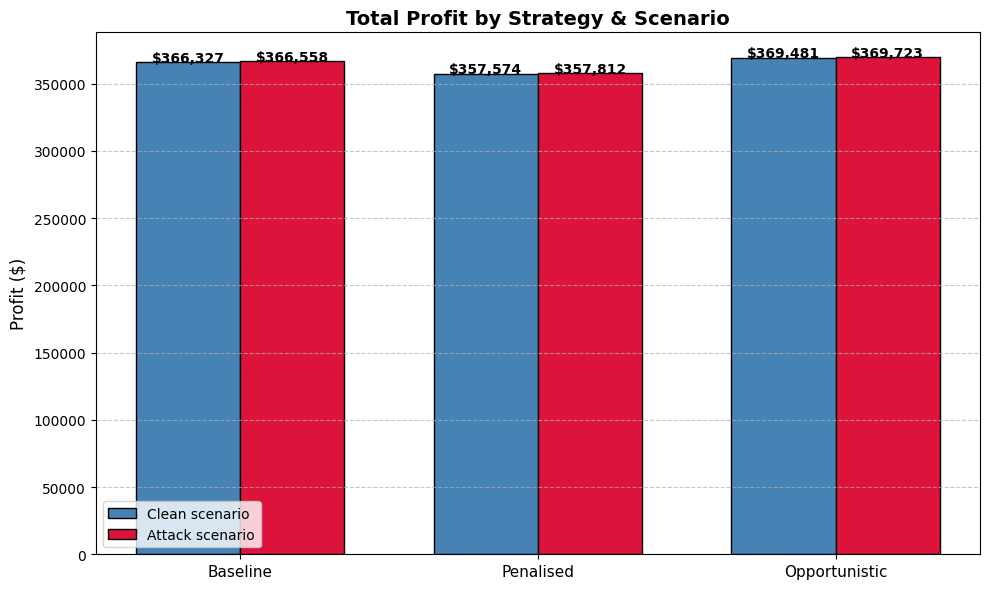

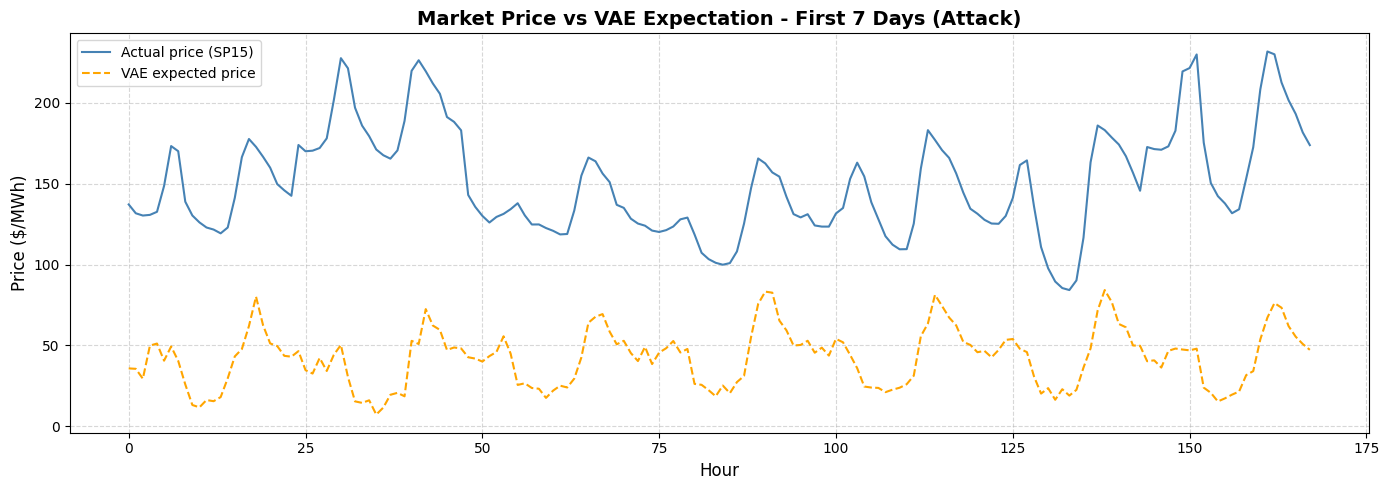

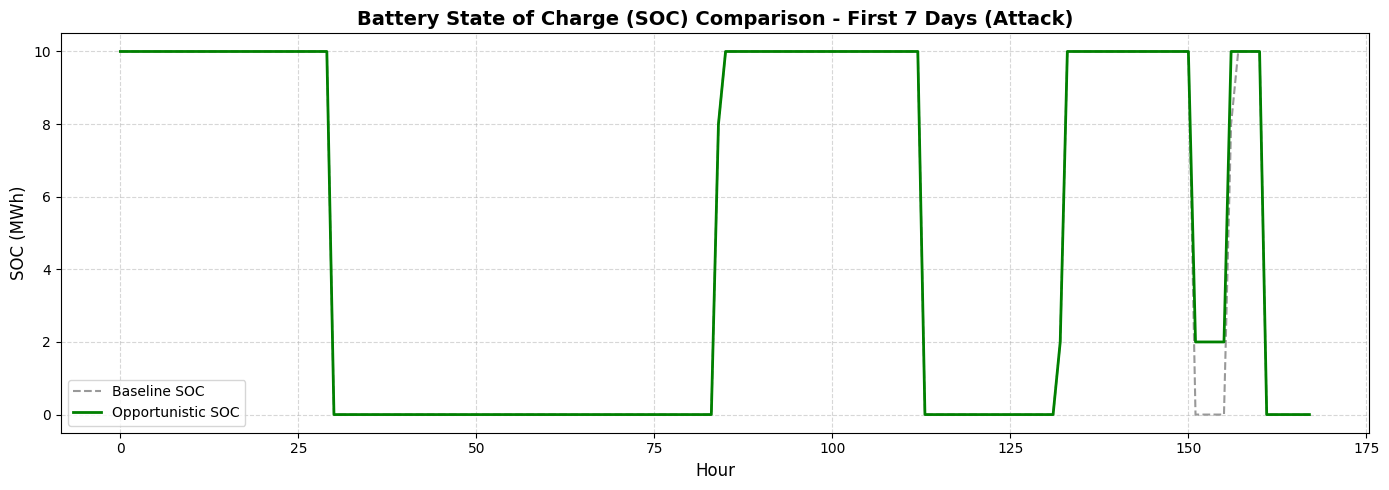

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def display_results_dashboard():
    """Show the main plots for profit, price, and battery state of charge."""
    print("Generating interactive visualizations...")

    labels = ['Baseline', 'Penalised', 'Opportunistic']
    clean_profits = [c_base, c_pen, c_opp]
    attack_profits = [a_base, a_pen, a_opp]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, clean_profits, width, label='Clean scenario', color='steelblue', edgecolor='black')
    ax.bar(x + width/2, attack_profits, width, label='Attack scenario', color='crimson', edgecolor='black')

    ax.set_ylabel('Profit ($)', fontsize=12)
    ax.set_title('Total Profit by Strategy & Scenario', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate each bar with its value so the chart can be read at a glance.
    for i, v in enumerate(clean_profits):
        ax.text(i - width/2, v + 100, f"${v:,.0f}", ha='center', fontweight='bold')
    for i, v in enumerate(attack_profits):
        ax.text(i + width/2, v + 100, f"${v:,.0f}", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Plot the first 7 days so the lines stay readable.
    plot_window = 168

    plt.figure(figsize=(14, 5))
    plt.plot(attack_df['SP15'].values[:plot_window], label='Actual price (SP15)', color='steelblue')
    plt.plot(attack_df['expected_price'].values[:plot_window], label='VAE expected price', color='orange', linestyle='--')

    # Mark the hours that the pipeline classified as genuine anomalies.
    anom_idx = attack_df.index[(attack_df['is_genuine'] == 1) & (attack_df.index < plot_window)].tolist()
    if anom_idx:
        plt.scatter(anom_idx, attack_df['SP15'].iloc[anom_idx], color='red', s=50, label='Detected anomaly', zorder=5)

    plt.title('Market Price vs VAE Expectation - First 7 Days (Attack)', fontsize=14, fontweight='bold')
    plt.xlabel('Hour', fontsize=12)
    plt.ylabel('Price ($/MWh)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Compare the battery state of charge for the conservative and opportunistic strategies.
    plt.figure(figsize=(14, 5))
    plt.plot(a_soc_base[:plot_window], label='Baseline SOC', color='gray', linestyle='--', alpha=0.8)
    plt.plot(a_soc_opp[:plot_window], label='Opportunistic SOC', color='green', linewidth=2)

    plt.title('Battery State of Charge (SOC) Comparison - First 7 Days (Attack)', fontsize=14, fontweight='bold')
    plt.xlabel('Hour', fontsize=12)
    plt.ylabel('SOC (MWh)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

display_results_dashboard()

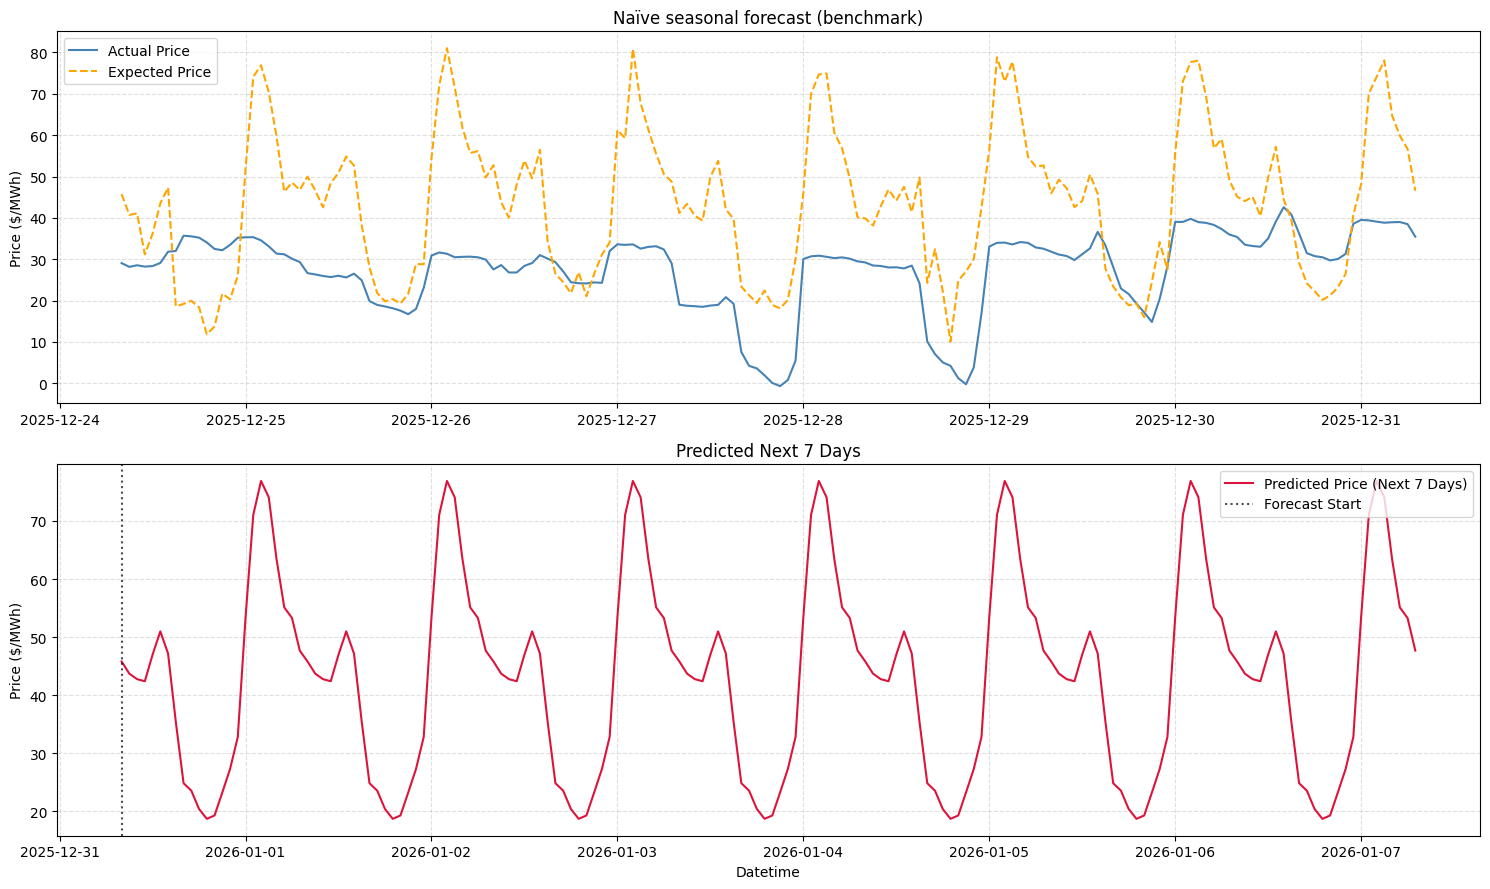

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_last_7_days_and_next_7_days(df, name='attack'):
    """Show the recent history and a simple naive 7-day forward benchmark."""
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])

    window_hours = 24 * 7
    history = df.tail(window_hours).reset_index(drop=True)

    if 'expected_price' not in history.columns:
        raise KeyError('expected_price column missing. Run the model pipeline first.')

    # Build a naive 7-day forecast from the last 7 days of hourly averages.
    expected_values = history['expected_price'].to_numpy()
    if len(expected_values) >= window_hours:
        hourly_profile = expected_values[:window_hours].reshape(7, 24).mean(axis=0)
    else:
        hourly_profile = np.resize(expected_values[-24:], 24)

    forecast_values = np.tile(hourly_profile, 7)
    future_start = history['datetime'].iloc[-1] + pd.Timedelta(hours=1)
    future_index = pd.date_range(start=future_start, periods=window_hours, freq='h')

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

    axes[0].plot(history['datetime'], history['SP15'], label='Actual Price', color='steelblue')
    axes[0].plot(history['datetime'], history['expected_price'], label='Expected Price', color='orange', linestyle='--')
    axes[0].set_title('Naïve seasonal forecast (benchmark)')
    axes[0].set_ylabel('Price ($/MWh)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(future_index, forecast_values, label='Predicted Price (Next 7 Days)', color='crimson')
    axes[1].axvline(future_index[0], color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    axes[1].set_title('Predicted Next 7 Days')
    axes[1].set_ylabel('Price ($/MWh)')
    axes[1].set_xlabel('Datetime')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_last_7_days_and_next_7_days(attack_df, name='attack')

In [50]:
def calculate_performance_metrics(profit, soc_list, capacity_mwh=10.0):
    """Compute EFC and profit per cycle from the SOC trajectory."""
    total_discharge_mwh = 0.0

    # Accumulate discharge throughput hour by hour.
    for t in range(1, len(soc_list)):
        if soc_list[t] < soc_list[t - 1]:
            total_discharge_mwh += (soc_list[t - 1] - soc_list[t])

    # Equivalent full cycles use total throughput, not only discharge.
    total_charge_mwh = sum(
        max(0, soc_list[t] - soc_list[t-1])
        for t in range(1, len(soc_list))
    )
    throughput = total_charge_mwh + total_discharge_mwh
    efc = throughput / (2 * capacity_mwh)

    # If the battery never moved, avoid a divide-by-zero here.
    profit_per_cycle = profit / efc if efc > 0 else 0.0

    return efc, profit_per_cycle


# Use the opportunistic outputs already computed in this notebook.
profit_value = globals().get("p_opp", globals().get("a_opp", globals().get("c_opp")))
soc_value = globals().get("soc_opp", globals().get("a_soc_opp", globals().get("c_soc_opp")))

if profit_value is None or soc_value is None:
    if 'run' not in globals():
        raise RuntimeError("The 'run' function is not defined. Please execute the cell that defines 'run()' first.")
    clean_df, c_base, c_pen, c_opp, c_soc_base, c_soc_pen, c_soc_opp, c_gradcam = run(merged_df_clean)
    attack_df, a_base, a_pen, a_opp, a_soc_base, a_soc_pen, a_soc_opp, a_gradcam = run(merged_df_spike)
    profit_value = a_opp
    soc_value = a_soc_opp

efc_opp, ppc_opp = calculate_performance_metrics(profit_value, soc_value, capacity_mwh=10.0)
print(f"Opportunistic Strategy:")
print(f"  Total Profit: ${profit_value:,.2f}")
print(f"  Equivalent Full Cycles (EFC): {efc_opp:.1f} cycles")
print(f"  Profit per Cycle: ${ppc_opp:,.2f}/cycle")

Opportunistic Strategy:
  Total Profit: $369,723.40
  Equivalent Full Cycles (EFC): 1050.5 cycles
  Profit per Cycle: $351.95/cycle


In [ ]:
def calculate_performance_metrics(profit, soc_list, capacity_mwh=10.0):
    """Compute EFC and profit per cycle from the SOC trajectory."""
    total_discharge_mwh = 0.0

    # Accumulate discharge throughput hour by hour.
    for t in range(1, len(soc_list)):
        if soc_list[t] < soc_list[t - 1]:
            total_discharge_mwh += (soc_list[t - 1] - soc_list[t])

    # Equivalent full cycles use total throughput, not only discharge.
    total_charge_mwh = sum(
        max(0, soc_list[t] - soc_list[t-1])
        for t in range(1, len(soc_list))
    )
    throughput = total_charge_mwh + total_discharge_mwh
    efc = throughput / (2 * capacity_mwh)

    # If the battery never moved, avoid a divide-by-zero here.
    profit_per_cycle = profit / efc if efc > 0 else 0.0

    return efc, profit_per_cycle


# Use the opportunistic outputs already computed in this notebook.
profit_value = globals().get("p_opp", globals().get("a_opp", globals().get("c_opp")))
soc_value = globals().get("soc_opp", globals().get("a_soc_opp", globals().get("c_soc_opp")))

if profit_value is None or soc_value is None:
    if 'run' not in globals():
        raise RuntimeError("The 'run' function is not defined. Please execute the cell that defines 'run()' first.")
    clean_df, c_base, c_pen, c_opp, c_soc_base, c_soc_pen, c_soc_opp, c_gradcam = run(merged_df_clean)
    attack_df, a_base, a_pen, a_opp, a_soc_base, a_soc_pen, a_soc_opp, a_gradcam = run(merged_df_spike)
    profit_value = a_opp
    soc_value = a_soc_opp

efc_opp, ppc_opp = calculate_performance_metrics(profit_value, soc_value, capacity_mwh=10.0)
print(f"Opportunistic Strategy:")
print(f"  Total Profit: ${profit_value:,.2f}")
print(f"  Equivalent Full Cycles (EFC): {efc_opp:.1f} cycles")
print(f"  Profit per Cycle: ${ppc_opp:,.2f}/cycle")

Starting sensitivity sweep...
Solving for sensitivity = 0.0...
Solving for sensitivity = 0.1...
Solving for sensitivity = 0.2...
Solving for sensitivity = 0.3...
Solving for sensitivity = 0.4...
Solving for sensitivity = 0.5...
Solving for sensitivity = 0.6...
Solving for sensitivity = 0.7...
Solving for sensitivity = 0.8...
Solving for sensitivity = 0.9...
Solving for sensitivity = 1.0...
Sweep complete. Generating figure...


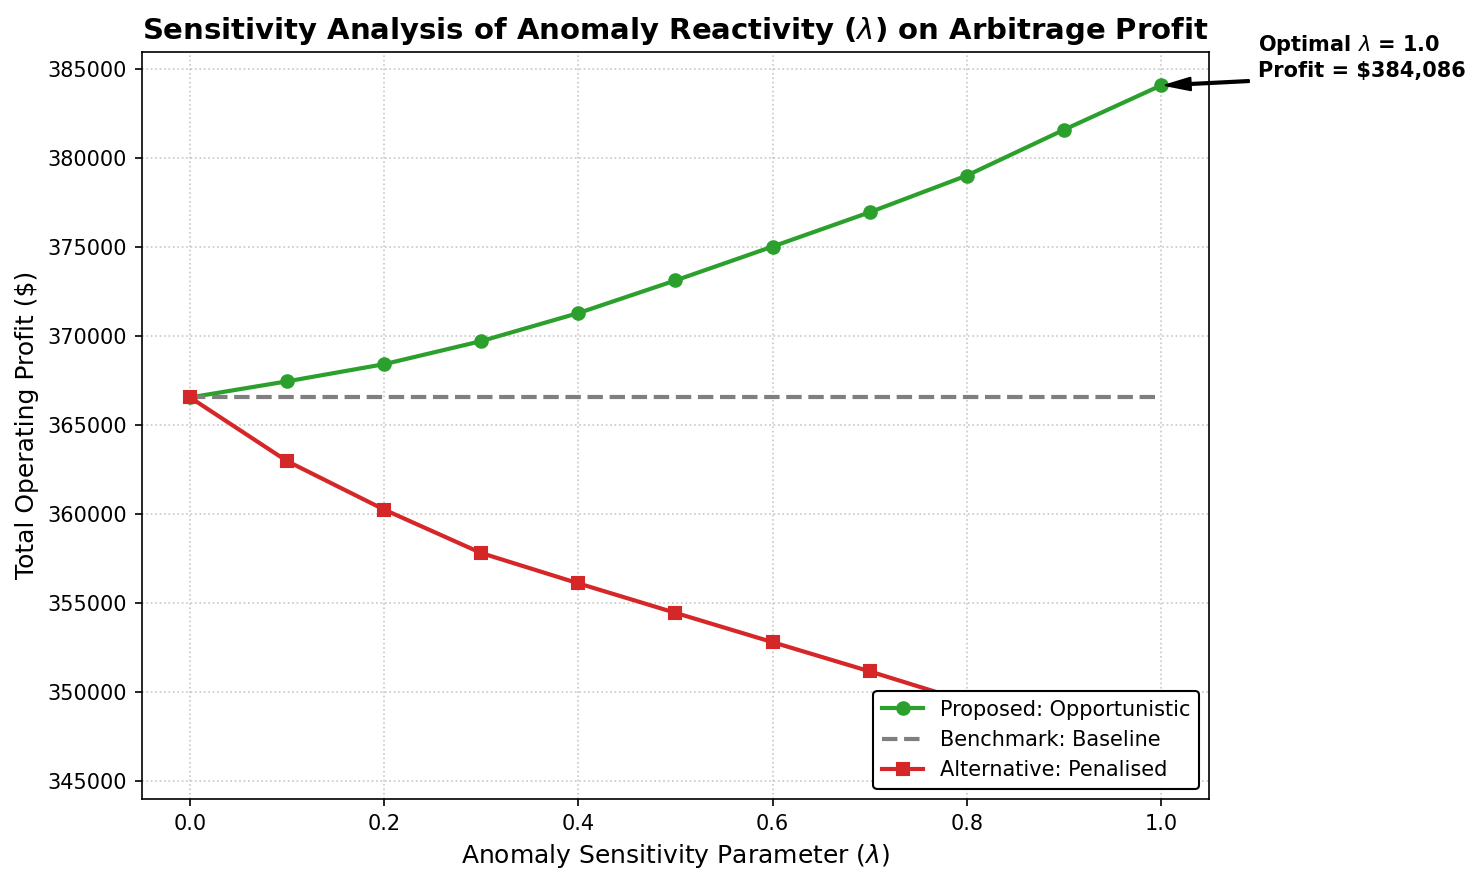

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def run_sensitivity_analysis():
    """Sweep the anomaly-sensitivity parameter and plot the resulting profits."""
    print("Starting sensitivity sweep...")

    sensitivities = np.linspace(0.0, 1.0, 11)

    opp_profits = []
    pen_profits = []

    # Reuse the same Laplacian for every run so the comparison stays consistent.
    L = build_graph(merged_df_spike)
    base_profit, _ = optimize(attack_df, L=L, mode="baseline", anomaly_sensitivity=0)
    baseline_profits = [base_profit] * len(sensitivities)

    for s in sensitivities:
        print(f"Solving for sensitivity = {s:.1f}...")
        p_opp, _ = optimize(attack_df, L=L, mode="opportunistic", anomaly_sensitivity=s)
        p_pen, _ = optimize(attack_df, L=L, mode="penalised", anomaly_sensitivity=s)

        opp_profits.append(p_opp)
        pen_profits.append(p_pen)

    print("Sweep complete. Generating figure...")

    plt.figure(figsize=(10, 6), dpi=150)
    plt.plot(sensitivities, opp_profits, marker='o', color='#2ca02c', linewidth=2, label='Proposed: Opportunistic')
    plt.plot(sensitivities, baseline_profits, linestyle='--', color='#7f7f7f', linewidth=2, label='Benchmark: Baseline')
    plt.plot(sensitivities, pen_profits, marker='s', color='#d62728', linewidth=2, label='Alternative: Penalised')

    best_idx = np.argmax(opp_profits)
    best_s = sensitivities[best_idx]
    best_p = opp_profits[best_idx]

    plt.annotate(f'Optimal $\\lambda$ = {best_s:.1f}\nProfit = ${best_p:,.0f}', 
                 xy=(best_s, best_p), xytext=(best_s + 0.1, best_p + 500),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 fontsize=10, fontweight='bold')

    plt.title("Sensitivity Analysis of Anomaly Reactivity ($\\lambda$) on Arbitrage Profit", fontsize=14, fontweight='bold')
    plt.xlabel("Anomaly Sensitivity Parameter ($\\lambda$)", fontsize=12)
    plt.ylabel("Total Operating Profit ($)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower right', framealpha=1.0, edgecolor='black')

    plt.tight_layout()
    plt.show()

run_sensitivity_analysis()